In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
r0=2*G*Mbh/c**2


In [32]:
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["figure.dpi"] = 100

In [33]:
temperatures = np.loadtxt('../debugOutput/findHighTemp.csv')
print(np.max(temperatures))

1002210000000.0


In [34]:
tdeFile = h5py.File('../data/tdestream.out1.01335.athdf', 'r')
print(list(tdeFile.keys()))

['B', 'Levels', 'LogicalLocations', 'prim', 'x1f', 'x1v', 'x2f', 'x2v', 'x3f', 'x3v']


In [35]:
arguments = {'data_file': '../data/tdestream.out1.01335.athdf', 'quantity': 'press', 'output_file': './plots/pressPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
press = plot_slice.getDataSlice(**arguments)
print(press.shape)

(512, 1024)


In [36]:
arguments = {'data_file': '../data/tdestream.out1.01335.athdf', 'quantity': 'rho', 'output_file': './plots/rhoPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
rho = plot_slice.getDataSlice(**arguments)
print(rho.shape)

(512, 1024)


In [21]:
rho0=1e-8
kT = mu*mp*((v0**2)*rho0*press)/(rho*rho0)
T = kT/kB

In [22]:
print(np.max(T))

86952140.0


slice location 0.5 yielded max T around 8.97e9

slice location 0.0 yielded max T around 5.66e11

for tdestream.out1.01335.athdf

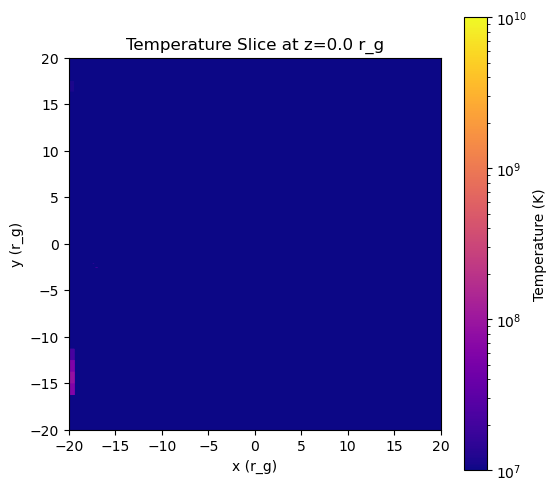

In [28]:
plt.imshow(T, origin='lower', extent=[-20,20,-20,20], norm=LogNorm(vmin=1e7, vmax=1e10), cmap='plasma')
plt.colorbar(label='Temperature (K)')
plt.xlabel('x (r_g)')
plt.ylabel('y (r_g)')
plt.title('Temperature Slice at z=0.0 r_g')
plt.show()

In [37]:
tdeFile = h5py.File('../data/tdestream.out1.00600.athdf', 'r')
print(list(tdeFile.keys()))
arguments = {'data_file': '../data/tdestream.out1.00600.athdf', 'quantity': 'press', 'output_file': './plots/pressPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
press = plot_slice.getDataSlice(**arguments)
print(press.shape)
arguments = {'data_file': '../data/tdestream.out1.00600.athdf', 'quantity': 'rho', 'output_file': './plots/rhoPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
rho = plot_slice.getDataSlice(**arguments)
print(rho.shape)
rho0=1e-8
kT = mu*mp*((v0**2)*rho0*press)/(rho*rho0)
T = kT/kB

['B', 'Levels', 'LogicalLocations', 'prim', 'x1f', 'x1v', 'x2f', 'x2v', 'x3f', 'x3v']
(512, 1024)
(512, 1024)


In [39]:
np.average((rho*1e-8 / (mu * mp))**2)

1.2328568e+28

In [42]:
-np.average((rho*1e-8 / (mu * mp))**2)*3.55e-69*(G*Mbh/c**2)

-1.9387975349024597e-29

In [43]:
"{:.2E}".format(1-np.exp(-np.average((rho*1e-8 / (mu * mp))**2)*3.55e-69*10*(G*Mbh/c**2)))

'0.00E+00'

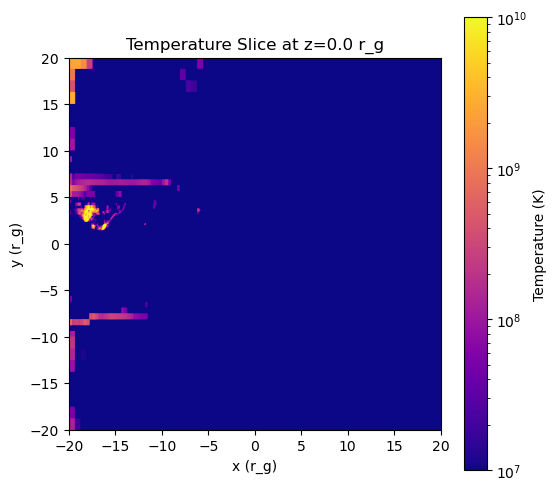

In [30]:
plt.imshow(T, origin='lower', extent=[-20,20,-20,20], norm=LogNorm(vmin=1e7, vmax=1e10), cmap='plasma')
plt.colorbar(label='Temperature (K)')
plt.xlabel('x (r_g)')
plt.ylabel('y (r_g)')
plt.title('Temperature Slice at z=0.0 r_g')
plt.show()

rayleigh jeans approx


In [44]:
a = 0.018*np.average(T**(-3/2))*np.average((rho*1e-8 / (mu * mp))**2)*1e-16
j = 6.8e-38*np.average((rho*1e-8 / (mu * mp))**2)*np.average(T**(-3/2))*1e-32

In [47]:
j/a

3.777777777777778e-52